<a href="https://colab.research.google.com/github/Daniphantom99/AW/blob/main/BACE1_DS_Activity_wall.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
!pip install rdkit
from rdkit import Chem
from rdkit.Chem import Descriptors
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
!pip install rdkit
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Scaffolds.MurckoScaffold import GetScaffoldForMol



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.4/37.4 MB 51.6 MB/s eta 0:00:00


In [2]:
#Database con propiedades fisicoquimicas KNIME.
database = pd.read_csv("/content/BACE1_DS_Descriptors_fingerprints_KNIME.csv")
print(database.shape)

(4716, 1085)


/tmp/ipykernel_2617/3563972237.py:2: DtypeWarning: Columns (1,46) have mixed types. Specify dtype option on import or set low_memory=False.
  database = pd.read_csv("/content/BACE1_DS_Descriptors_fingerprints_KNIME.csv")


In [3]:
#Conocer las columnas
database.columns[:60]

Index(['Molecule ChEMBL ID', 'Molecule Name', 'Smiles', 'Standard Type',
       'Standard Relation', 'Standard Value', 'Standard Units',
       'Molecule Max Phase', 'Molecular Weight', '#RO5 Violations', 'AlogP',
       'Compound Key', 'Structure of Smiles [idcode]',
       'Structure of Smiles 2 [idcode]', 'pChEMBL Value',
       'Data Validity Comment', 'Comment', 'Uo Units', 'Ligand Efficiency BEI',
       'Ligand Efficiency LE', 'Ligand Efficiency LLE',
       'Ligand Efficiency SEI', 'Potential Duplicate', 'Assay ChEMBL ID',
       'Assay Description', 'Assay Type', 'BAO Format ID', 'BAO Label',
       'Assay Organism', 'Assay Tissue ChEMBL ID', 'Assay Tissue Name',
       'Assay Cell Type', 'Assay Subcellular Fraction', 'Assay Parameters',
       'Assay Variant Accession', 'Assay Variant Mutation', 'Target ChEMBL ID',
       'Target Name', 'Target Organism', 'Target Type', 'Document ChEMBL ID',
       'Source ID', 'Source Description', 'Document Journal', 'Document Year',
      

# Analisis de propiedades **fisicoquimicas** **texto en negrita**

/tmp/ipykernel_2617/241886567.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=database, x="NumHBD", ax=axes[0], palette="Blues_d")
/tmp/ipykernel_2617/241886567.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=database, x="NumHBA", ax=axes[1], palette="Creams_d" if "Creams_d" in dir(sns.color_palette) else "Oranges_d")
/tmp/ipykernel_2617/241886567.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=database, x="NumRotatableBonds", ax=axes[2], palette="Greens_d")


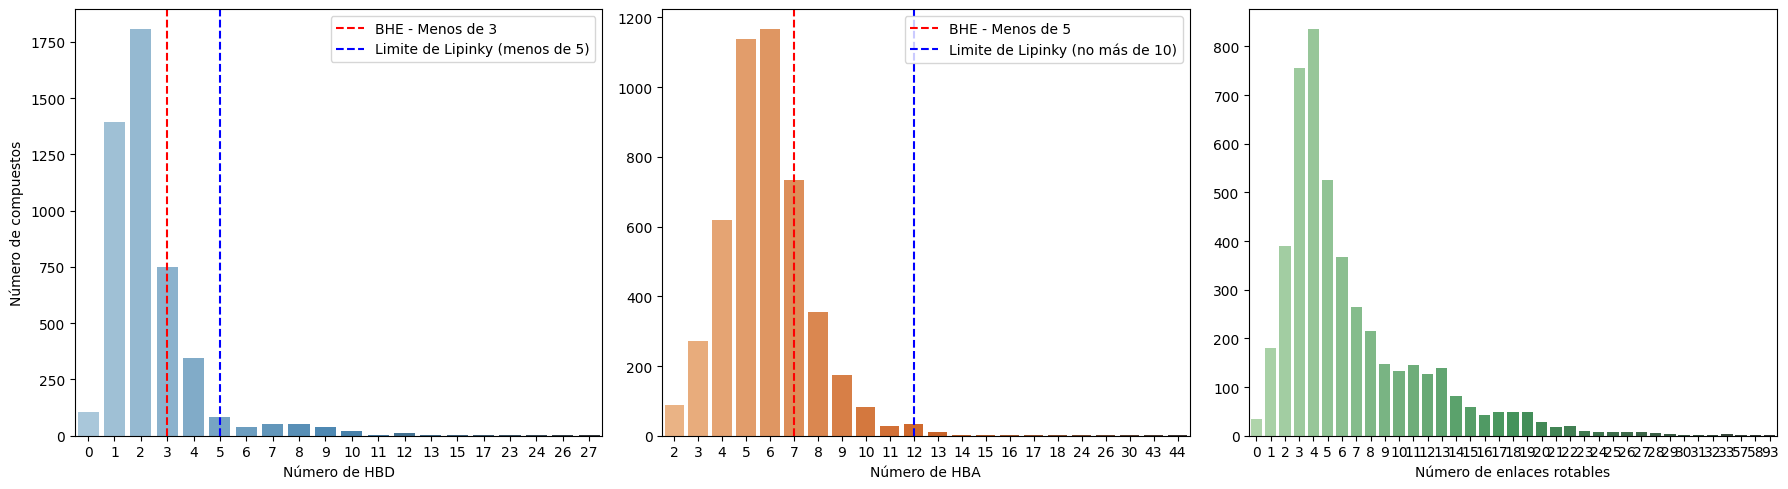

In [4]:
#Graficos para descriptores fisicoquimicos discretos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

#Dondadores de Enlace de puente de hidrógeno
sns.countplot(data=database, x="NumHBD", ax=axes[0], palette="Blues_d")
#axes[0].set_title("Distribución del número de átomos donadores de puente de hidrógeno")
axes[0].axvline(3, color="red", linestyle="--", label="BHE - Menos de 3")
axes[0].axvline(5, color="blue", linestyle="--", label="Limite de Lipinky (menos de 5)")
axes[0].set_xlabel("Número de HBD")
axes[0].set_ylabel("Número de compuestos")
axes[0].legend()

# Gráfico 2: Aceptores de Enlace de Hidrógeno
sns.countplot(data=database, x="NumHBA", ax=axes[1], palette="Creams_d" if "Creams_d" in dir(sns.color_palette) else "Oranges_d")
axes[1].axvline(5, color="red", linestyle="--", label="BHE - Menos de 5")
axes[1].axvline(10, color="blue", linestyle="--", label="Limite de Lipinky (no más de 10)")
#axes[1].set_title("Distribución del número de átomos aceptores de puente de hidrógeno")
axes[1].set_xlabel("Número de HBA")
axes[1].set_ylabel("")
axes[1].legend()

# Gráfico 3: Enlaces Rotables
sns.countplot(data=database, x="NumRotatableBonds", ax=axes[2], palette="Greens_d")
#axes[2].set_title("Distribución del número de enlaces rotables")
axes[2].set_xlabel("Número de enlaces rotables")
axes[2].set_ylabel("")


plt.tight_layout()
plt.show()


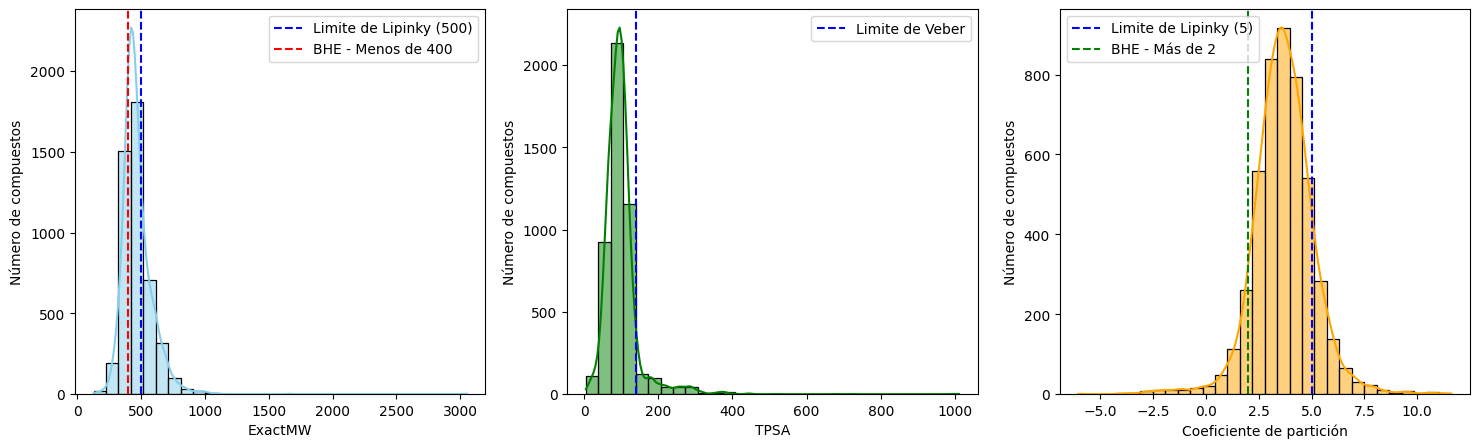

In [5]:
#Graficos para descriptores fisicoquimicos con valores continuos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(data=database, x="ExactMW", kde=True, ax=axes[0], color="skyblue", bins=30)

axes[0].axvline(500, color="blue", linestyle="--", label="Limite de Lipinky (500)")
axes[0].axvline(400, color="red", linestyle="--", label="BHE - Menos de 400")
#axes[0].set_title("Distribution of Molecular Weight")
axes[1].set_xlabel("Peso molar")
axes[0].set_ylabel("Número de compuestos")
axes[0].legend()

sns.histplot(data=database, x="TPSA", kde=True, ax=axes[1], color="green", bins=30)
axes[1].axvline(140, color="blue", linestyle="--", label="Limite de Veber")
axes[1].set_xlabel("TPSA")
axes[1].set_ylabel("Número de compuestos")
axes[1].legend()

sns.histplot(data=database, x="SlogP", kde=True, ax=axes[2], color="orange", bins=30)
axes[2].axvline(5, color="blue", linestyle="--", label="Limite de Lipinky (5)")
axes[2].axvline(2, color="green", linestyle="--", label="BHE - Más de 2")
axes[2].set_xlabel("Coeficiente de partición")
axes[2].set_ylabel("Número de compuestos")
axes[2].legend(loc='upper left')


plt.show()

/tmp/ipykernel_2617/2201352790.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
/tmp/ipykernel_2617/2201352790.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[1].legend()


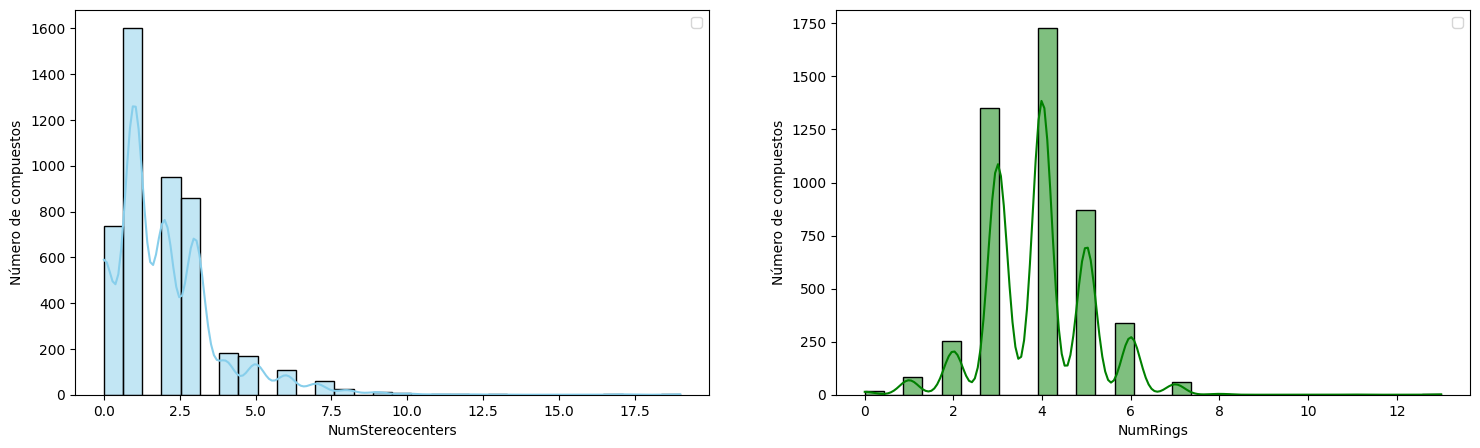

In [6]:
#Graficos para descriptores fisicoquimicos con valores continuos
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

sns.histplot(data=database, x="NumStereocenters", kde=True, ax=axes[0], color="skyblue", bins=30)

#axes[0].set_title("Distribution of Estereocenters")
axes[1].set_xlabel("#Estereocenters")
axes[0].set_ylabel("Número de compuestos")
axes[0].legend()

sns.histplot(data=database, x="NumRings", kde=True, ax=axes[1], color="green", bins=30)
axes[1].set_xlabel("NumRings")
axes[1].set_ylabel("Número de compuestos")
axes[1].legend()


plt.show()

In [7]:
#Analisis estadistico
columnas_descr = ["ExactMW", "SlogP", "TPSA", "NumHBA", "NumHBD", "NumRotatableBonds", "NumStereocenters", "NumRings"]

estaditica_desc = database[columnas_descr].describe()
print(estaditica_desc)

           ExactMW        SlogP         TPSA       NumHBA       NumHBD  \
count  4716.000000  4716.000000  4716.000000  4716.000000  4716.000000   
mean    468.882920     3.678473   100.206660     5.888889     2.341603   
std     127.194719     1.439128    50.485737     2.119033     1.852611   
min     126.031694    -6.044800     4.930000     2.000000     0.000000   
25%     398.095764     2.873375    74.640000     5.000000     1.000000   
50%     445.129902     3.658610    93.260000     6.000000     2.000000   
75%     516.170225     4.485430   111.720000     7.000000     3.000000   
max    3050.605836    11.609400  1010.420000    44.000000    27.000000   

       NumRotatableBonds  NumStereocenters     NumRings  
count        4716.000000       4716.000000  4716.000000  
mean            6.585666          1.954411     3.912850  
std             5.340583          1.741710     1.168442  
min             0.000000          0.000000     0.000000  
25%             3.000000          1.000000 

# Compuestos más potentes



In [8]:
print(database.columns[:50])

Index(['Molecule ChEMBL ID', 'Molecule Name', 'Smiles', 'Standard Type',
       'Standard Relation', 'Standard Value', 'Standard Units',
       'Molecule Max Phase', 'Molecular Weight', '#RO5 Violations', 'AlogP',
       'Compound Key', 'Structure of Smiles [idcode]',
       'Structure of Smiles 2 [idcode]', 'pChEMBL Value',
       'Data Validity Comment', 'Comment', 'Uo Units', 'Ligand Efficiency BEI',
       'Ligand Efficiency LE', 'Ligand Efficiency LLE',
       'Ligand Efficiency SEI', 'Potential Duplicate', 'Assay ChEMBL ID',
       'Assay Description', 'Assay Type', 'BAO Format ID', 'BAO Label',
       'Assay Organism', 'Assay Tissue ChEMBL ID', 'Assay Tissue Name',
       'Assay Cell Type', 'Assay Subcellular Fraction', 'Assay Parameters',
       'Assay Variant Accession', 'Assay Variant Mutation', 'Target ChEMBL ID',
       'Target Name', 'Target Organism', 'Target Type', 'Document ChEMBL ID',
       'Source ID', 'Source Description', 'Document Journal', 'Document Year',
      

In [9]:
#Analisis de top compuestos más potentes. Obtención de estructuras.
"""Los valores de potencia estan en la columna de Stanndar value y sus Unidades en Standar Units
Todos los compuestos están en nM"""
print(database["Standard Value"][:5])
print(database["Standard Units"][:5])


0        3.6
1        6.6
2        3.1
3       10.0
4    10000.0
Name: Standard Value, dtype: float64
0    nM
1    nM
2    nM
3    nM
4    nM
Name: Standard Units, dtype: object


In [10]:
#Revisar que database solo tiene compuestos activos.
print(database["Comment"].unique())

[     nan  235204.  235202. ...  751856.  482811. 1097569.]


In [11]:
database_potency = database.sort_values(by="Standard Value")
database_potency["Potency[μM]"] = (database_potency['Standard Value'] / 1000).round(7)


In [12]:
print(database_potency["Standard Value"][:20])

1764    0.20
3652    0.20
3787    0.20
2732    0.20
1755    0.20
1763    0.20
937     0.20
1632    0.20
1761    0.30
2729    0.30
1748    0.30
1758    0.30
3709    0.30
1762    0.30
1765    0.30
1707    0.30
1757    0.30
2347    0.30
1753    0.30
3616    0.31
Name: Standard Value, dtype: float64


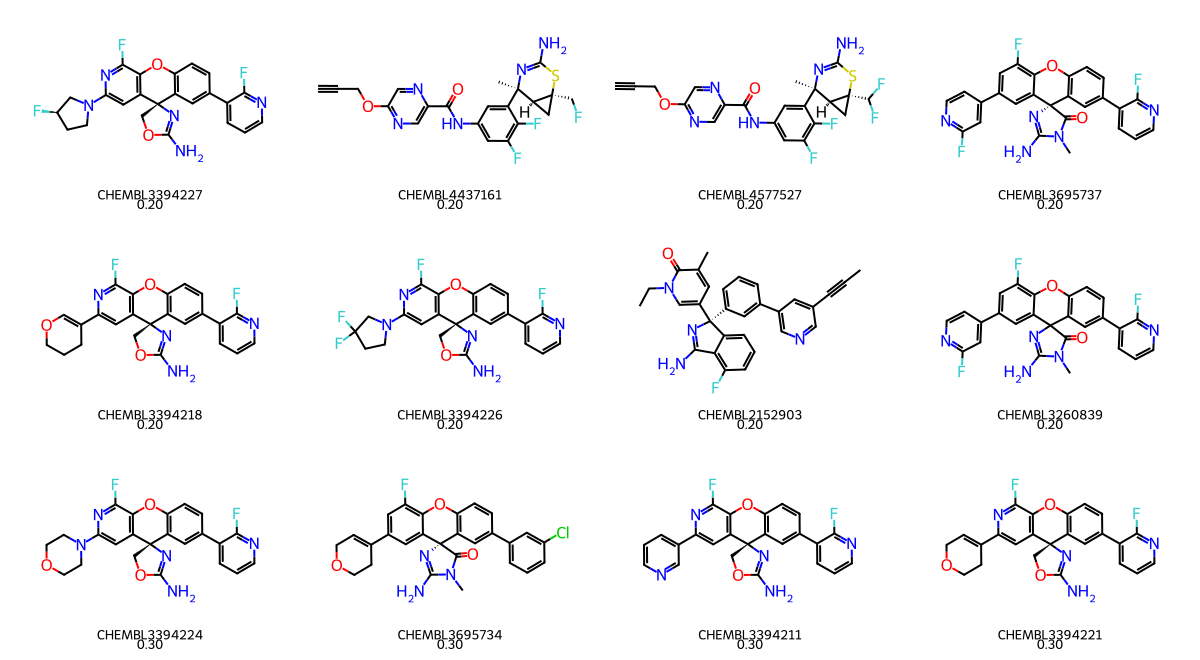

In [13]:
#Top 12 most potent compounds
#activity en nM
top_12 = database_potency.head(12)

mols = [Chem.MolFromSmiles(s) for s in top_12["Smiles"]]

leyendas = [
    f"{row['Molecule ChEMBL ID']}\n{row['Standard Value']:.2f}"
    for _, row in top_12.iterrows()
]

drawer_options = Draw.MolDrawOptions()
drawer_options.legendFontSize = 20
drawer_options.baseFontSize = 1.2


img = Draw.MolsToGridImage(
    mols,
    molsPerRow=4,
    subImgSize=(300, 220),
    legends=leyendas,
    drawOptions=drawer_options
)

img

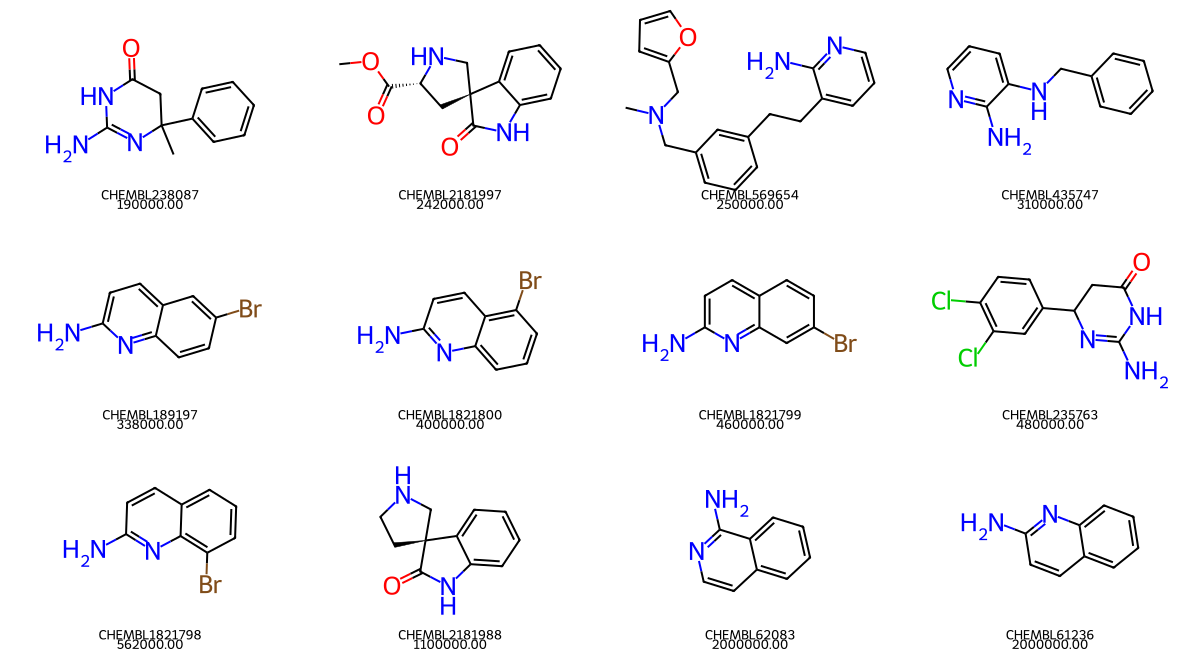

In [14]:
#Top 12 less potent compounds
#Potency in nM
top_12_l = database_potency.tail(12)

mols = [Chem.MolFromSmiles(s) for s in top_12_l["Smiles"]]

leyendas = [
    f"{row['Molecule ChEMBL ID']}\n{row['Standard Value']:.2f}"
    for _, row in top_12_l.iterrows()
]

drawer_options = Draw.MolDrawOptions()
drawer_options.legendFontSize = 20
drawer_options.baseFontSize = 1.2


img = Draw.MolsToGridImage(
    mols,
    molsPerRow=4,
    subImgSize=(300, 220),
    legends=leyendas,
    drawOptions=drawer_options
)

img

# Núcleos estructurales

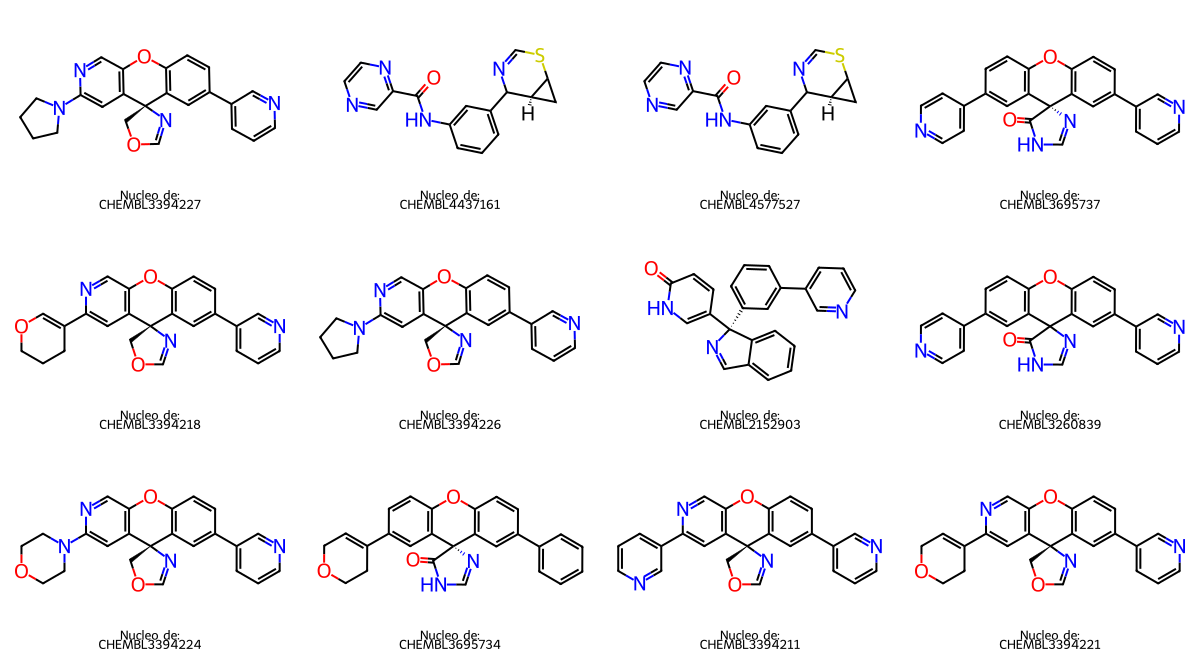

In [15]:
#Generar scaffolds
database_potency["mols"] = [Chem.MolFromSmiles(smile) for smile in database_potency["Smiles"]]
database_potency["scaffolds"] = [GetScaffoldForMol(mol) for mol in database_potency["mols"]]

top_12_scaffolds = database_potency.head(12)

mols_a_dibujar = top_12_scaffolds["scaffolds"].tolist()

leyendas = [
    f"Nucleo de:\n{row['Molecule ChEMBL ID']}"
    for _, row in top_12_scaffolds.iterrows()
]

drawer_options = Draw.MolDrawOptions()
drawer_options.legendFontSize = 20
drawer_options.baseFontSize = 1.2


sca = Draw.MolsToGridImage(
    mols_a_dibujar,
    molsPerRow=4,
    subImgSize=(300, 220),
    legends=leyendas,
    drawOptions=drawer_options
)

sca



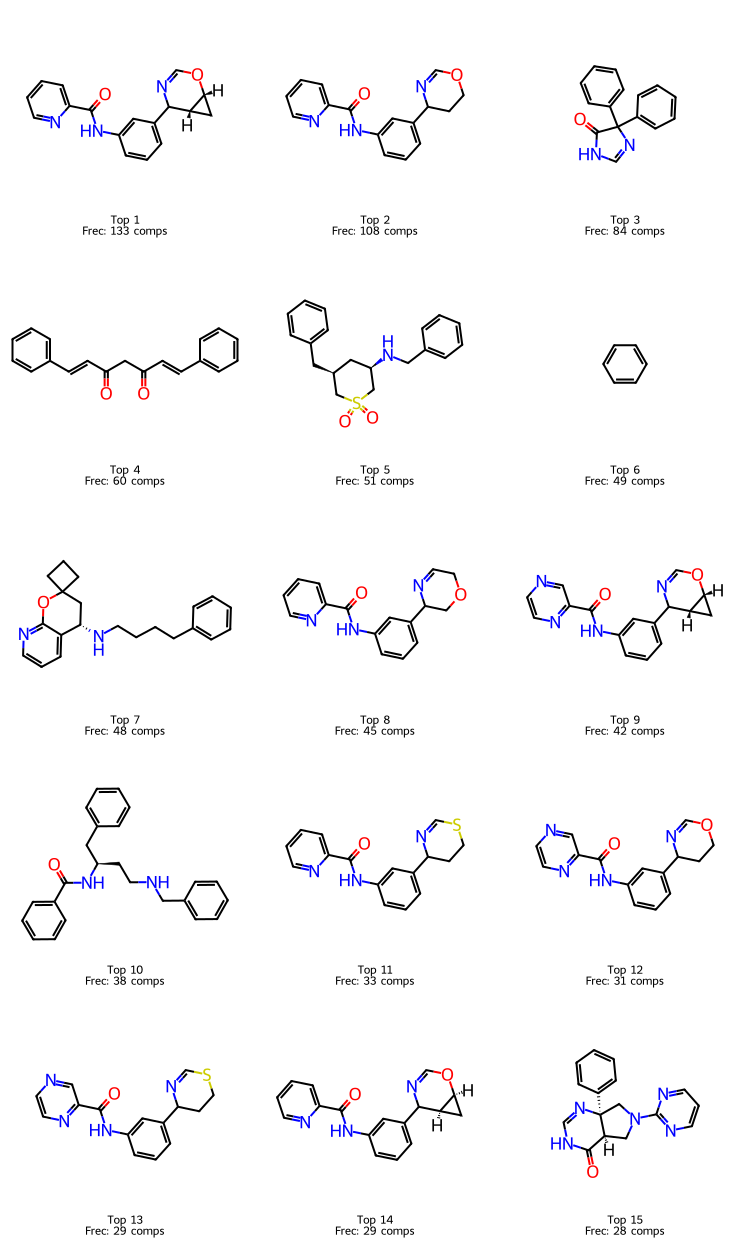

In [16]:
database_potency["scaffolds_smiles"] = [
    Chem.MolToSmiles(scaffold, canonical=True) if scaffold is not None else None
    for scaffold in database_potency["scaffolds"]
]

#Agrupar y contar frecuencias
scaffolds_counts = database_potency["scaffolds_smiles"].value_counts().reset_index()
scaffolds_counts.columns = ["Scaffold SMILES", "Frecuencia"]

#print("=== TOP 15 SCAFFOLDS MÁS FRECUENTES ===")
#print(scaffolds_counts.head(10))

top_15_scaffolds = scaffolds_counts.head(15)

scaffolds_a_dibujar = [Chem.MolFromSmiles(s) for s in top_15_scaffolds["Scaffold SMILES"]]

leyendas = [
    f"Top {i+1}\nFrec: {row['Frecuencia']} comps"
    for i, row in top_15_scaffolds.iterrows()
]

drawer_options = Draw.MolDrawOptions()
drawer_options.legendFontSize = 16
drawer_options.baseFontSize = 1.2
drawer_options.bondLineWidth = 2

top = Draw.MolsToGridImage(
    scaffolds_a_dibujar,
    molsPerRow=3,
    subImgSize=(250, 250),
    legends=leyendas,
    drawOptions=drawer_options
)

top


# Filtro de moleculas con propiedades para filtrar la BHE

# LiPE plots


In [17]:
#Actividad del dataset esta en IC50 (unidades nM). La conversion inicia con generar la colimna pIC50 atraves de:
database["pIC50"] = 9 - np.log10(database["Standard Value"])

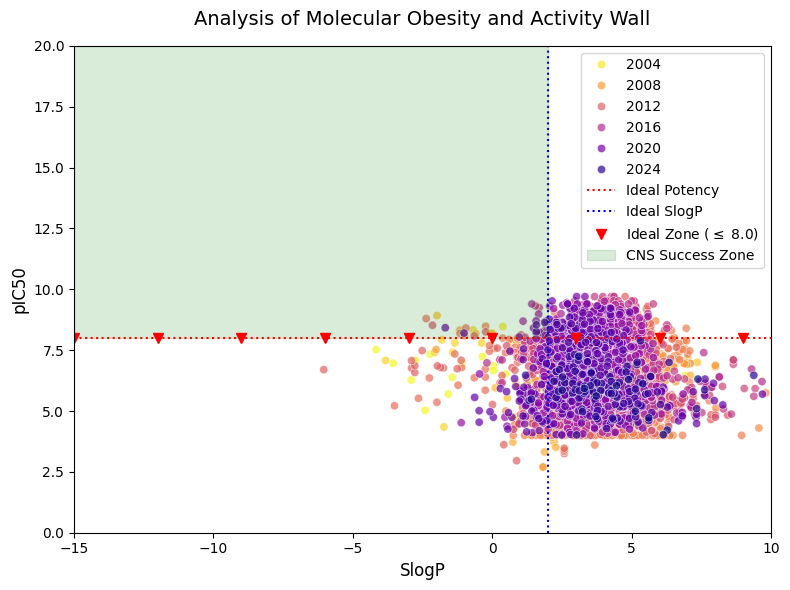

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))


sns.scatterplot(
    data=database.sort_values(by="Document Year"),
    x="SlogP",
    y="pIC50",
    hue="Document Year",
    palette="plasma_r",
    alpha=0.7,
)


plt.xlabel("SlogP", fontsize=12)
plt.ylabel("pIC50", fontsize=12)
plt.ylim(0, 20)
plt.xlim(-15, 10)

plt.axhline(y=8, color="red", linestyle=":", linewidth=1.5, label="Ideal Potency")
plt.axvline(x=2, color="blue", linestyle=":", linewidth=1.5, label="Ideal SlogP")

x_arrows = np.arange(-15, 11, 3)
y_arrows = np.full_like(x_arrows, 8)

# Zona de éxito: SlogP <= 2 y pIC50 >= 8
# Ajustamos el límite inferior de x a -15 para que coincida exactamente con tu xlim
plt.plot(
    x_arrows,
    y_arrows,
    color="red",
    linestyle="None",  # Evita que se dibuje otra línea
    marker="v",  # 'v' es el marcador de flecha hacia abajo
    markersize=7,
    label=r"Ideal Zone ($\leq$ 8.0)",
)

plt.fill_between(
    x=[-15, 2],
    y1=8,
    y2=20,
    color="green",
    alpha=0.15,
    label="CNS Success Zone",
)

# Configuración de la leyenda para que no se duplique y muestre las etiquetas correctas
plt.legend(loc="upper right")
plt.title(
    "Analysis of Molecular Obesity and Activity Wall",
    fontsize=14,
    pad=15,
)
plt.tight_layout()

plt.show()

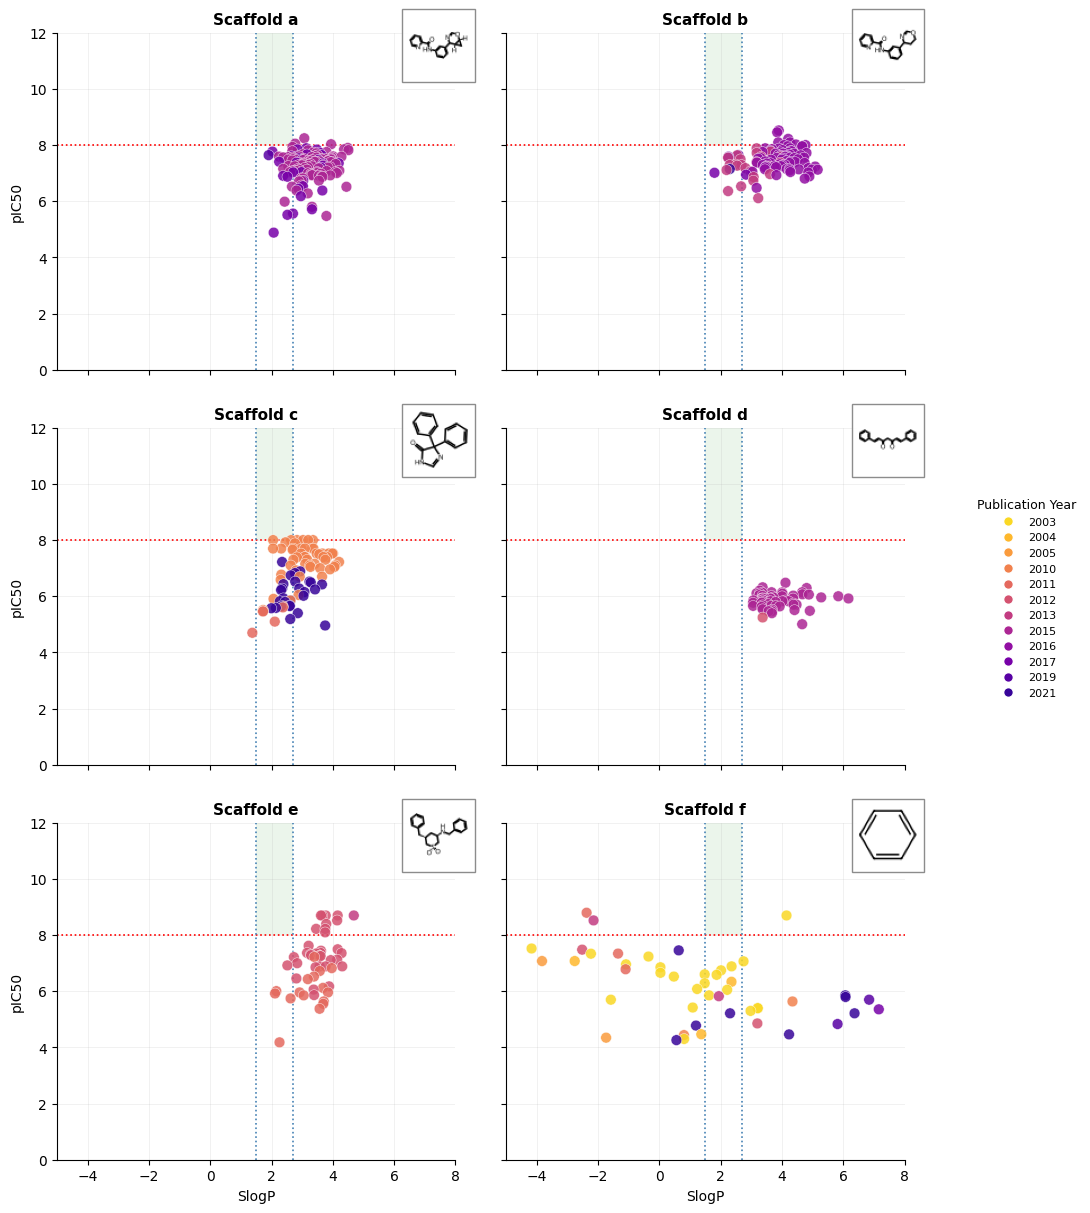

In [19]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.patches import Rectangle
import seaborn as sns
import numpy as np
import pandas as pd

from rdkit import Chem
from rdkit.Chem import Draw
from matplotlib.lines import Line2D


database_potency["pIC50"] = 9 - np.log10(database_potency["Standard Value"])

database_potency["Document Year"] = pd.to_numeric(
    database_potency["Document Year"],
    errors="coerce"
)

top_6_smiles = scaffolds_counts.head(6)["Scaffold SMILES"].tolist()

df_top6 = database_potency[
    (database_potency["scaffolds_smiles"].isin(top_6_smiles)) &
    (database_potency["Document Year"].notna())
].copy()


years = sorted(df_top6["Document Year"].dropna().astype(int).unique())

palette = sns.color_palette(
    "plasma_r",
    n_colors=len(years)
)

year_to_color = dict(zip(years, palette))

g = sns.FacetGrid(
    data=df_top6,
    col="scaffolds_smiles",
    col_order=top_6_smiles,
    col_wrap=2,
    height=4,
    aspect=1.3,
    sharex=True,
    sharey=True
)



drawer_options = Draw.MolDrawOptions()
drawer_options.clearBackground = True
drawer_options.bondLineWidth = 1.5
drawer_options.updateAtomPalette(
    {i:(0,0,0) for i in range(100)}
)


xmin = -5
xmax = 8

ymin = 0
ymax = 12

letters = ["a","b","c","d","e","f"]


for i,(smiles,ax) in enumerate(zip(top_6_smiles,g.axes.flat)):

    subset = df_top6[
        df_top6["scaffolds_smiles"]==smiles
    ]

    sc = ax.scatter(
      subset["SlogP"],
      subset["pIC50"],
      c=[year_to_color[int(y)] for y in subset["Document Year"]],
      s=60,
      edgecolor="white",
      linewidth=0.35,
      alpha=0.85,
      zorder=3
      )

    rect = Rectangle(
          (1.5, 8),
          1.2,
          4,
          facecolor="green",
          alpha=0.08,
          linewidth=0,
          zorder=0
      )

    ax.add_patch(rect)


    ax.axhline(
        8,
        color="red",
        ls=":",
        lw=1.2
    )

    ax.axvline(
        1.5,
        color="steelblue",
        ls=":",
        lw=1.2
    )

    ax.axvline(
        2.7,
        color="steelblue",
        ls=":",
        lw=1.2
    )



    ax.set_xlim(xmin,xmax)
    ax.set_ylim(ymin,ymax)



    mol = Chem.MolFromSmiles(smiles)

    if mol is not None:

        img = Draw.MolToImage(
            mol,
            size=(55,55),
            options=drawer_options
        )

        imagebox = OffsetImage(
            img,
            zoom=0.80
        )

        ab = AnnotationBbox(
            imagebox,
            (xmax-0.55,ymax-0.45),
            frameon=True,
            bboxprops=dict(
                facecolor="white",
                edgecolor="gray",
                alpha=0.90
            )
        )

        ax.add_artist(ab)


    ax.set_title(
        f"Scaffold {letters[i]}",
        fontsize=11,
        weight="bold"
    )

    ax.grid(
        alpha=0.25,
        linewidth=0.5
    )

    sns.despine(ax=ax)


g.set_axis_labels(
    "SlogP",
    "pIC50"
)



legend_elements = [
    Line2D(
        [0],
        [0],
        marker='o',
        color='w',
        markerfacecolor=year_to_color[y],
        markersize=7,
        label=str(y)
    )
    for y in years
]

g.figure.legend(
    handles=legend_elements,
    title="Publication Year",
    loc="center left",
    bbox_to_anchor=(0.92,0.5),
    frameon=False,
    fontsize=8,
    title_fontsize=9
)

plt.subplots_adjust(
    right=0.86
)

plt.show()


In [20]:
import pandas as pd
from rdkit import Chem

# 1. Asegurar que los años sean enteros limpios en el DataFrame principal
database_potency["Document Year"] = pd.to_numeric(database_potency["Document Year"], errors='coerce').astype("Int64")

# 2. Extraer el Top 6 de scaffolds
top_6_smiles = scaffolds_counts.head(6)["Scaffold SMILES"].tolist()

# 3. Filtrar la base de datos para estos 6 scaffolds con año válido
df_resumen = database_potency[
    database_potency["scaffolds_smiles"].isin(top_6_smiles) &
    database_potency["Document Year"].notna()
].copy()

# 4. Construir la tabla resumen combinando agregaciones
tabla_scaffolds = (
    df_resumen.groupby("scaffolds_smiles")["Document Year"]
    .agg(
        Num_Compuestos="count",
        Años_Activos=lambda x: sorted(list(x.unique())),
        Año_Inicio="min",
        Año_Fin="max"
    )
    .reset_index()
)

# 5. Calcular el periodo total de estudio en años
tabla_scaffolds["Periodo_Estudio (Años)"] = (tabla_scaffolds["Año_Fin"] - tabla_scaffolds["Año_Inicio"]) + 1

# 6. Ordenar la tabla para que coincida exactamente con tu Top 6 del conteo original
tabla_scaffolds["scaffolds_smiles"] = pd.Categorical(tabla_scaffolds["scaffolds_smiles"], categories=top_6_smiles, ordered=True)
tabla_scaffolds = tabla_scaffolds.sort_values("scaffolds_smiles").reset_index(drop=True)

# 7. Asignar una etiqueta clara de "Top" para identificar cuál es cuál en tus gráficos
tabla_scaffolds.insert(0, "Ranking", [f"Top {i+1}" for i in range(len(tabla_scaffolds))])

# 8. Formatear la lista de años como string elegante para visualización de tablas
tabla_scaffolds["Años_Activos"] = tabla_scaffolds["Años_Activos"].apply(lambda lista: ", ".join(map(str, lista)))

# Visualizar la tabla en el Notebook
display(tabla_scaffolds)

,Ranking,scaffolds_smiles,Num_Compuestos,Años_Activos,Año_Inicio,Año_Fin,Periodo_Estudio (Años)
0,Top 1,O=C(Nc1cccc(C2N=CO[C@@H]3C[C@H]23)c1)c1ccccn1,133,"2015, 2017, 2019",2015,2019,5
1,Top 2,O=C(Nc1cccc(C2CCOC=N2)c1)c1ccccn1,108,"2013, 2016, 2017, 2021",2013,2021,9
2,Top 3,O=C1NC=NC1(c1ccccc1)c1ccccc1,84,"2010, 2011, 2021",2010,2021,12
3,Top 4,O=C(/C=C/c1ccccc1)CC(=O)/C=C/c1ccccc1,60,"2012, 2015",2012,2015,4
4,Top 5,O=S1(=O)C[C@@H](Cc2ccccc2)C[C@@H](NCc2ccccc2)C1,51,"2011, 2012, 2013",2011,2013,3
5,Top 6,c1ccccc1,49,"2003, 2004, 2005, 2010, 2011, 2012, 2013, 2017...",2003,2021,19


In [21]:
import pandas as pd

# 1. Asegurar que tenemos calculado el LipE en el DataFrame general
df_top6["LipE"] = df_top6["pIC50"] - df_top6["SlogP"]

# 2. Agrupar por scaffold calculando promedios, máximos y desviaciones estándar
summary_metrics = (
    df_top6.groupby("scaffolds_smiles")
    .agg(
        Frecuencia=("scaffolds_smiles", "count"),
        pIC50_Max=("pIC50", "max"),
        pIC50_Promedio=("pIC50", "mean"),
        pIC50_SD=("pIC50", "std"),  # <--- Desviación Estándar de pIC50
        SlogP_Promedio=("SlogP", "mean"),
        SlogP_SD=("SlogP", "std"),  # <--- Desviación Estándar de SlogP
        LipE_Max=("LipE", "max"),
        LipE_Promedio=("LipE", "mean"),
        LipE_SD=("LipE", "std"),  # <--- Desviación Estándar de LipE
        # Identificar qué molécula específica es la mejor en eficiencia lipofílica
        Best_Molecule_ID=(
            "Molecule ChEMBL ID",
            lambda x: df_top6.loc[x.index]
            .sort_values(by="LipE", ascending=False)["Molecule ChEMBL ID"]
            .iloc[0],
        ),
    )
    .reset_index()
)

# 3. Ordenar la tabla por frecuencia (de mayor a menor)
summary_metrics = summary_metrics.sort_values(by="Frecuencia", ascending=False).reset_index(drop=True)

# 4. Formatear los decimales para estilo de publicación científica
pd.options.display.float_format = "{:,.2f}".format

# 5. Desplegar la tabla con las nuevas columnas estadísticas
print("=== TABLA RESUMEN DE EFICIENCIA POR SCAFFOLD (CON SD) ===")
print(
    summary_metrics[
        [
            "Frecuencia",
            "pIC50_Max",
            "pIC50_Promedio",
            "pIC50_SD",
            "SlogP_Promedio",
            "SlogP_SD",
            "LipE_Max",
            "LipE_Promedio",
            "LipE_SD",
            "Best_Molecule_ID",
        ]
    ]
)

=== TABLA RESUMEN DE EFICIENCIA POR SCAFFOLD (CON SD) ===
   Frecuencia  pIC50_Max  pIC50_Promedio  pIC50_SD  SlogP_Promedio  SlogP_SD  \
0         133       8.24            7.21      0.55            3.24      0.55   
1         108       8.52            7.44      0.40            3.74      0.76   
2          84       8.00            6.77      0.88            2.91      0.63   
3          60       6.48            5.85      0.27            3.87      0.67   
4          51       8.70            7.00      1.01            3.48      0.55   
5          49       8.80            6.16      1.16            1.24      2.98   

   LipE_Max  LipE_Promedio  LipE_SD Best_Molecule_ID  
0      5.74           3.97     0.71    CHEMBL3688820  
1      5.33           3.70     0.76    CHEMBL4226208  
2      5.95           3.86     0.81    CHEMBL1271453  
3      2.95           1.98     0.71    CHEMBL3672445  
4      5.09           3.52     0.87    CHEMBL2048058  
5     12.74           4.92     3.65     CHEMBL41276

Analisis y filtro de compuestos con buen perfil LipE. Si tienen buen valor de lipofilidad y son muy activos, ¿Por qué no se han seguido estudiando/ porqué no estan en el mercado?

Posible respuesta:
-Generan efectos adversos por presencia de toxicoforos
-Tienen estructuras tipo PAINS




In [22]:
#Identificación de los compuestos con un perfil adecuado: Actividad pIC50 mayor a 8, sLogp 1.5 a 2.7
#Pero tambien otras propiedades fisicoquimicas ideales para permear


database_potency_1 = database_potency.copy()

#Definir las condiciones utilizando el dataframe de entrada

cond_pIC50 = database_potency_1["pIC50"] >= 8.0
cond_slogp = (database_potency_1["SlogP"] >= 1.5) & (database_potency_1["SlogP"] <= 2.7)
#cond_mw = df_resultado["ExactMW"] <= 500
#cond_hba = df_resultado["NumHBA"] <= 6
#cond_hbd = df_resultado["NumHBD"] <= 3
#cond_tpsa = df_resultado["TPSA"] <= 90

#Combinar todas las reglas en un filtro lógico (solo lipE + sLogP)
filtro_ideal = cond_pIC50 & cond_slogp

#Combinar todas las reglas en un filtro lógico (para permeabilidad de BBB)
#filtro_ideal = cond_pIC50 & cond_slogp & cond_mw & cond_hba & cond_hbd & cond_tpsa

#Asignar la etiqueta en una nueva columna ("Sí" si cumple todas, "No" si falla al menos una)
database_potency_1["Ideal_Perfil"] = "No"
database_potency_1.loc[filtro_ideal, "Ideal_Perfil"] = "Sí"

#Reporte estadístico sin recortar el dataset
total_compuestos = len(database_potency_1)
total_ideales = filtro_ideal.sum()
total_no_ideales = total_compuestos - total_ideales

print(f"Total de compuestos en el dataset: {total_compuestos}")
print(f"Total de compuestos ideales: {total_ideales} (equivalente al {((total_ideales / total_compuestos) * 100):.2f}%)")
print(f"Total de compuestos no ideales: {total_no_ideales} (equivalente al {((total_no_ideales / total_compuestos) * 100):.2f}%)")

BACE1_ideal = database_potency_1[database_potency_1["Ideal_Perfil"] == "Sí"].copy()


Total de compuestos en el dataset: 4716
Total de compuestos ideales: 86 (equivalente al 1.82%)
Total de compuestos no ideales: 4630 (equivalente al 98.18%)


# Toxicoforos en BACE1 ideal


In [23]:
from rdkit import Chem
from rdkit.Chem import FilterCatalog
import pandas as pd

def etiquetar_toxicoforos_brenk(BACE1_ideal, columna_smiles="Smiles", archivo_salida="ideal_brenk.csv"):
    """
    Evalúa la presencia de toxicóforos o alertas estructurales (reglas de Brenk et al.)
    en el dataset 'BACE1_ideal'. Añade columnas nominales sin eliminar compuestos
    y exporta el resultado final a un archivo CSV.
    """

    # 1. Configurar el catálogo explícitamente para BRENK
    params = FilterCatalog.FilterCatalogParams()
    params.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.BRENK)
    catalogo_brenk = FilterCatalog.FilterCatalog(params)

    es_toxicoforo_nominal = []
    motivo_toxicoforo = []

    print("Iniciando análisis estructural de la quimioteca...")

    # 2. Análisis molecular ciclo por ciclo
    for s in BACE1_ideal[columna_smiles]:
        mol = Chem.MolFromSmiles(s)

        if mol is None:
            es_toxicoforo_nominal.append("Sí")
            motivo_toxicoforo.append("SMILES Inválido")
            continue

        # Verificar si hace match con alguna alerta estructural de Brenk
        if catalogo_brenk.HasMatch(mol):
            es_toxicoforo_nominal.append("Sí")
            match = catalogo_brenk.GetFirstMatch(mol)
            motivo_toxicoforo.append(match.GetDescription())
        else:
            es_toxicoforo_nominal.append("No")
            motivo_toxicoforo.append("Limpio")

    # 3. Añadir las columnas de diagnóstico a una copia del dataset original para no alterarlo
    ideal_brenk = BACE1_ideal.copy()
    ideal_brenk["Tiene_Toxicoforo"] = es_toxicoforo_nominal
    ideal_brenk["Motivo_Toxicoforo"] = motivo_toxicoforo

    # 4. Reporte estadístico global
    total_evaluadas = len(ideal_brenk)
    total_toxicos = es_toxicoforo_nominal.count("Sí")
    total_limpios = es_toxicoforo_nominal.count("No")

    print("-" * 50)
    print("REPORTE GLOBAL DE TOXICÓFOROS (REGLAS BRENK)")
    print("-" * 50)
    print(f"Total de moléculas evaluadas en BACE1_ideal: {total_evaluadas}")
    print(f"Compuestos con toxicóforos / alertas estructurales: {total_toxicos} ({(total_toxicos / total_evaluadas) * 100:.2f} %)")
    print(f"Compuestos limpios (Estructuralmente seguros): {total_limpios} ({(total_limpios / total_evaluadas) * 100:.2f} %)")
    print("-" * 50)

    # 5. Exportar el dataset completo con sus nuevas columnas nominales a CSV
    # CORRECCIÓN: Se cambió 'df_resultado' por el nombre correcto del DataFrame 'ideal_brenk'
    ideal_brenk.to_csv(archivo_salida, index=False)
    print(f"¡Éxito! Dataset global guardado correctamente en: '{archivo_salida}'")
    print("=" * 50)

    return ideal_brenk

# CORRECCIÓN: Se eliminó el "2" sobrante al final de la línea
ideal_brenk = etiquetar_toxicoforos_brenk(
    BACE1_ideal, columna_smiles="Smiles", archivo_salida="ideal_brenk.csv"
)

Iniciando análisis estructural de la quimioteca...
--------------------------------------------------
REPORTE GLOBAL DE TOXICÓFOROS (REGLAS BRENK)
--------------------------------------------------
Total de moléculas evaluadas en BACE1_ideal: 86
Compuestos con toxicóforos / alertas estructurales: 25 (29.07 %)
Compuestos limpios (Estructuralmente seguros): 61 (70.93 %)
--------------------------------------------------
¡Éxito! Dataset global guardado correctamente en: 'ideal_brenk.csv'


# PAINS
 Identificación de PAINS en los ideales de BACE1

In [24]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import FilterCatalog


def eliminar_pains(df_entrada, columna_smiles="Smiles"):
    """Identifica y elimina moléculas que contienen subestructuras PAINS

    utilizando los catálogos oficiales de RDKit (Familia PAINS_A).
    """
    # Usando el catálogo PAINS_A
    params = FilterCatalog.FilterCatalogParams()
    params.AddCatalog(FilterCatalog.FilterCatalogParams.FilterCatalogs.PAINS_A)
    catalogo_pains = FilterCatalog.FilterCatalog(params)

    # Listas para almacenar los resultados del escaneo
    es_pains = []
    motivo_pains = []

    # Loop para evaluar cada SMILES
    for s in df_entrada[columna_smiles]:
        mol = Chem.MolFromSmiles(str(s))

        if mol is None:
            es_pains.append(True)
            motivo_pains.append("SMILES Inválido")
            continue

        # Verificar si la molécula hace match con algún filtro PAINS_A
        if catalogo_pains.HasMatch(mol):
            es_pains.append(True)
            match = catalogo_pains.GetFirstMatch(mol)
            motivo_pains.append(match.GetDescription())
        else:
            es_pains.append(False)
            motivo_pains.append("Limpio")

    # Crear el DataFrame de diagnóstico
    df_diagnostico = df_entrada.copy()
    df_diagnostico["Es_PAINS"] = es_pains
    df_diagnostico["Motivo_PAINS"] = motivo_pains

    # CORRECCIÓN CLAVE: Filtrar para dejar solo las moléculas limpias (Es_PAINS == False)
    df_limpio = df_diagnostico[df_diagnostico["Es_PAINS"] == False].copy()

    total_inicial = len(df_entrada)
    total_final = len(df_limpio)
    pains_detectados = total_inicial - total_final

    print("=" * 50)
    print("DETECCIÓN Y FILTRADO DE COMPUESTOS PAINS (FAMILIA A)")
    print("=" * 50)
    print(f"Moléculas iniciales: {total_inicial}")
    print(f"Moléculas limpias (sin PAINS): {total_final}")
    print(
        f"PAINS eliminados: {pains_detectados} ({(pains_detectados / total_inicial) * 100:.2f}%)"
    )
    print("=" * 50)

    # Retorna el dataframe estrictamente limpio y el de diagnóstico completo
    return df_limpio, df_diagnostico


# Llamada a la función (asumiendo que tu DataFrame previo se llama ideal_brenk)
ideal_brenk_pains, ideal_pains_diagnostico = eliminar_pains(
    ideal_brenk, columna_smiles="Smiles"
)

DETECCIÓN Y FILTRADO DE COMPUESTOS PAINS (FAMILIA A)
Moléculas iniciales: 86
Moléculas limpias (sin PAINS): 86
PAINS eliminados: 0 (0.00%)


# SAScore:
Los compuestos del dataset de BACE1 con mejor LipE exhibirán valores de SAScore elevados, lo que compromete su viabilidad sintética en el laboratorio. Esto representa una manifestación alternativa y ortogonal del 'Activity Wall'.


In [25]:
from rdkit import Chem  # CORRECCIÓN: Importación faltante para Chem.MolFromSmiles
from rdkit.Contrib.SA_Score import sascorer


# CORRECCIÓN DE IMPORTACIÓN: Configurar la ruta correcta al directorio 'Contrib' de RDKit


def calcular_sascore(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        return sascorer.calculateScore(mol) if mol is not None else None
    except:
        return None


print("Calculando SA_Score para el dataset depurado...")

# 3. Aplicar el cálculo a la columna de SMILES
ideal_brenk_pains["SA_Score"] = ideal_brenk_pains["Smiles"].apply(
    calcular_sascore
)

# 4. Clasificar la viabilidad sintética usando una condición lógica
# Si SA_Score > 5 -> No Viable (difícil de sintetizar), de lo contrario -> Viable
ideal_brenk_pains["Viabilidad_Sintetica"] = ideal_brenk_pains[
    "SA_Score"
].apply(lambda x: "No Viable" if x > 5 else "Viable" if pd.notnull(x) else "Error")

# 5. Reporte estadístico rápido en consola
total = len(ideal_brenk_pains)
viables = (ideal_brenk_pains["Viabilidad_Sintetica"] == "Viable").sum()
no_viables = (
    ideal_brenk_pains["Viabilidad_Sintetica"] == "No Viable"
).sum()

print("=" * 50)
print("ANÁLISIS DE ACCESIBILIDAD SINTÉTICA (SA_SCORE)")
print("=" * 50)
print(f"Total de compuestos evaluados: {total}")
print(f"Compuestos Viables (SA <= 5): {viables} ({(viables/total)*100:.2f}%)")
print(
    f"Compuestos No Viables (SA > 5): {no_viables} ({(no_viables/total)*100:.2f}%)"
)
print("=" * 50)

# 6. Guardar el nuevo dataset con las métricas de síntesis añadidas
ideal_brenk_pains.to_csv("ideal_brenk_pains_sa.csv", index=False)
print("¡Dataset guardado exitosamente como 'ideal_brenk_pains_sa.csv'!")

Calculando SA_Score para el dataset depurado...
ANÁLISIS DE ACCESIBILIDAD SINTÉTICA (SA_SCORE)
Total de compuestos evaluados: 86
Compuestos Viables (SA <= 5): 72 (83.72%)
Compuestos No Viables (SA > 5): 14 (16.28%)
¡Dataset guardado exitosamente como 'ideal_brenk_pains_sa.csv'!


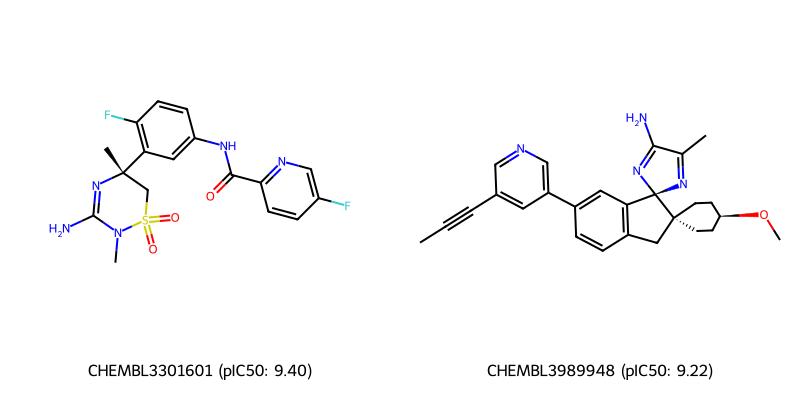

In [26]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import rdDepictor  # Importación para forzar coordenadas 2D claras

# 1. Filtrar el dataset para obtener los IDs de ChEMBL correctos
nombres_objetivo = ["CHEMBL3301601", "CHEMBL3989948"]
df_filtrado = database[database["Molecule ChEMBL ID"].isin(nombres_objetivo)]

moleculas = []
leyendas = []

# 2. Convertir SMILES a objetos Mol de RDKit y generar sus coordenadas 2D
for _, fila in df_filtrado.iterrows():
    smiles = fila["Smiles"]
    nombre = fila["Molecule ChEMBL ID"]
    potencia = (
        f" (pIC50: {fila['pIC50']:.2f})" if "pIC50" in df_filtrado.columns else ""
    )

    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        rdDepictor.Compute2DCoords(
            mol
        )  # CORRECCIÓN: Fuerza el cálculo correcto de la estructura en el plano
        moleculas.append(mol)
        leyendas.append(f"{nombre}{potencia}")

# 3. Dibujar las moléculas en una cuadrícula limpia asegurando el renderizado
if moleculas:
    img = Draw.MolsToGridImage(
        moleculas,
        molsPerRow=2,
        subImgSize=(
            400,
            400,
        ),  # Mantiene el tamaño amplio para las estructuras grandes de BACE1
        legends=leyendas,
        useSVG=False,  # CORRECCIÓN: PNG evita los errores de visualización de fondo invisible en Jupyter
    )
    display(img)
else:
    print(
        "No se encontraron las moléculas. Revisa si los IDs coinciden exactamente en la columna 'Molecule ChEMBL ID'."
    )

In [27]:
print(df_top6[df_top6["scaffolds_smiles"] == top_6_smiles[0]]["Document Year"].value_counts(dropna=False))

Document Year
2015    101
2017     31
2019      1
Name: count, dtype: int64


/tmp/ipykernel_2617/3916819253.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


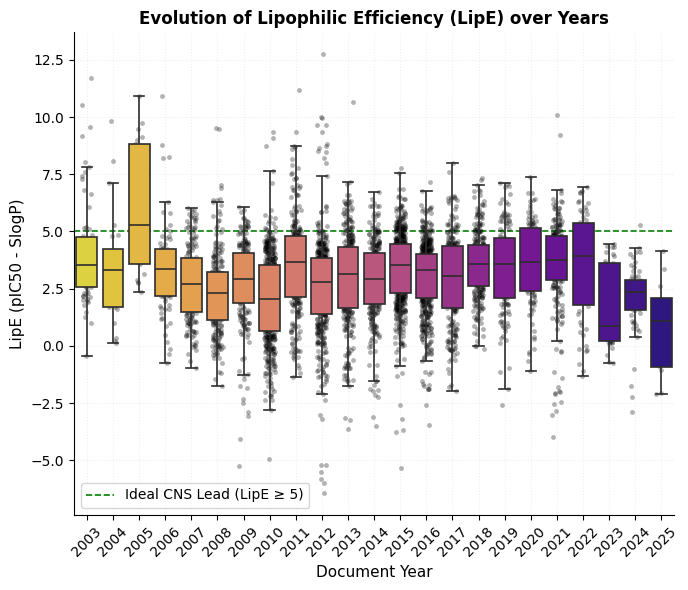

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Asegurar el cálculo de pIC50 y LipE en el DataFrame original
database_potency["pIC50"] = 9 - np.log10(database_potency["Standard Value"])
database_potency["LipE"] = database_potency["pIC50"] - database_potency["SlogP"]

# 2. Limpieza de años
df_clean = database_potency.dropna(subset=["Document Year", "LipE"]).copy()
df_clean["Document Year"] = pd.to_numeric(df_clean["Document Year"], errors="coerce")
df_clean = df_clean.dropna(subset=["Document Year"])
df_clean["Document Year"] = df_clean["Document Year"].astype(int)

# 3. Verificación de seguridad
if df_clean.empty:
    print("⚠️ Error: El DataFrame está vacío.")
else:
    # Ordenar cronológicamente
    df_clean = df_clean.sort_values(by="Document Year")

    # Configurar el estilo del gráfico cuadrado/limpio
    plt.figure(figsize=(7, 6))

    # 4. Graficar BOX PLOT
    # Usamos la paleta plasma_r mapeada a los años únicos
    sns.boxplot(
        data=df_clean,
        x="Document Year",
        y="LipE",
        palette="plasma_r",
        fliersize=0,      # Ocultamos outliers del boxplot para pintarlos con el stripplot
        linewidth=1.2,
        zorder=2
    )

    # 5. Agregar STRIPPLOT tenue encima (para ver los compuestos individuales de fondo)
    sns.stripplot(
        data=df_clean,
        x="Document Year",
        y="LipE",
        color="black",
        size=3.5,
        alpha=0.3,
        jitter=0.2,       # Dispersión horizontal para que no se encimen
        zorder=1
    )

    # Añadir línea de referencia (LipE >= 5 es el estándar de oro en Drug Design)
    plt.axhline(y=5, color="green", linestyle="--", linewidth=1.2, label="Ideal CNS Lead (LipE ≥ 5)", zorder=0)

    # Formato y estilo
    plt.title("Evolution of Lipophilic Efficiency (LipE) over Years", fontsize=12, fontweight="bold")
    plt.xlabel("Document Year", fontsize=11)
    plt.ylabel("LipE (pIC50 - SlogP)", fontsize=11)
    plt.xticks(rotation=45)
    plt.grid(alpha=0.2, linestyle=":")
    plt.legend(loc="lower left")

    sns.despine()
    plt.tight_layout()
    plt.show()

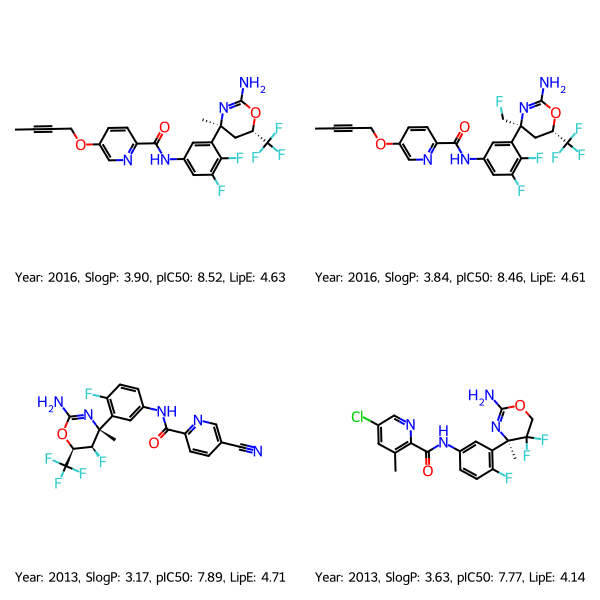

In [29]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw

scaffold_5_smiles = scaffolds_counts.iloc[1]["Scaffold SMILES"]

df_scaffold_5 = database_potency[
    database_potency["scaffolds_smiles"] == scaffold_5_smiles
].copy()


columna_año = "Document Year"
columna_mol_smiles = "Smiles"
columna_slogp = "SlogP"
columna_ic50 = "pIC50"
columna_lipe = "LipE"
columna_id_mol = "Molecule ChEMBL ID"


df_por_año = df_scaffold_5.groupby(columna_año).head(2).reset_index(drop=True)

años_a_incluir = df_por_año[columna_año].unique()[:4]

df_4_años = df_por_año[df_por_año[columna_año].isin(años_a_incluir)].reset_index(drop=True)


df_4_años = df_scaffold_5.groupby(columna_año).head(2).reset_index()
df_4_años = df_4_años.head(4)


moleculas_a_dibujar = []
leyendas = []

for idx, fila in df_4_años.iterrows():
    smiles = fila[columna_mol_smiles]
    año = fila[columna_año]
    slogp = fila[columna_slogp]
    ic50 = fila[columna_ic50]
    lipe = fila[columna_lipe]
    id_mol = fila[columna_id_mol]

    mol = Chem.MolFromSmiles(str(smiles))
    if mol is not None:
        moleculas_a_dibujar.append(mol)

        # La magia ocurre aquí con el formato {:.2f} que fuerza 2 decimales
        leyendas.append(
            f"Year: {int(año)}, SlogP: {slogp:.2f}, pIC50: {ic50:.2f}, LipE: {lipe:.2f}"
        )


drawer_options = Draw.MolDrawOptions()
drawer_options.legendFontSize = 16
drawer_options.baseFontSize = 1.2
drawer_options.bondLineWidth = 2


top = Draw.MolsToGridImage(
    moleculas_a_dibujar,
    molsPerRow=2,
    subImgSize=(300, 300),
    legends=leyendas,
    drawOptions=drawer_options,
)

top

📊 Desplegando pares de compuestos para el Top 1
-> Años encontrados en este set: [np.int64(2015), np.int64(2017), np.int64(2019)]


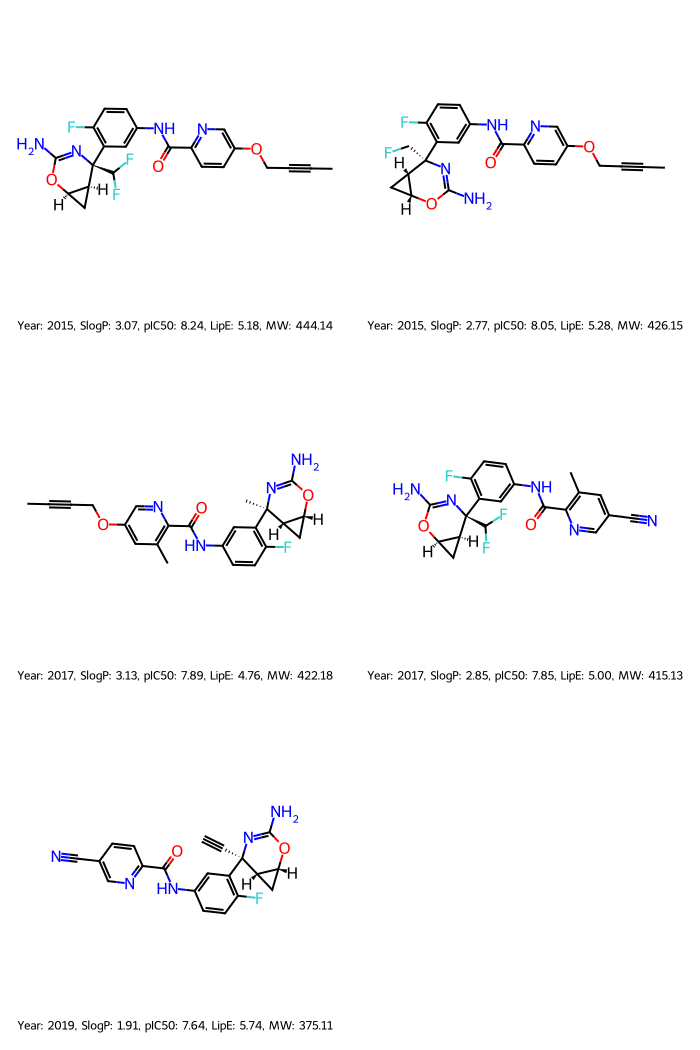

In [33]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw


ranking_deseado = 1


scaffold_seleccionado_smiles = top_6_smiles[ranking_deseado - 1]


df_scaffold_especifico = database_potency[
    (database_potency["scaffolds_smiles"] == scaffold_seleccionado_smiles) &
    (database_potency["Document Year"].notna())
].copy()

columna_año = "Document Year"
columna_mol_smiles = "Smiles"
columna_slogp = "SlogP"
columna_ic50 = "pIC50"
columna_lipe = "LipE"
columna_mw = "ExactMW"


df_final_grid = df_scaffold_especifico.groupby(columna_año).head(2).reset_index(drop=True)


df_final_grid = df_final_grid.sort_values(columna_año).reset_index(drop=True)

moleculas_a_dibujar = []
leyendas = []

for idx, fila in df_final_grid.iterrows():
    smiles = fila[columna_mol_smiles]
    año = fila[columna_año]
    slogp = fila[columna_slogp]
    ic50 = fila[columna_ic50]
    lipe = fila[columna_lipe]
    MW = fila[columna_mw]

    mol = Chem.MolFromSmiles(str(smiles))
    if mol is not None:
        moleculas_a_dibujar.append(mol)
        # Aplicamos el formato :.2f para asegurar el redondeo visual homogéneo
        leyendas.append(
            f"Year: {int(año)}, SlogP: {slogp:.2f}, pIC50: {ic50:.2f}, LipE: {lipe:.2f}, MW: {MW:.2f}"
        )

# ==============================================================================
# 4. CONFIGURACIÓN ESTÉTICA Y DESPLIEGUE DEL GRID IMAGE
# ==============================================================================
print(f"📊 Desplegando pares de compuestos para el Top {ranking_deseado}")
print(f"-> Años encontrados en este set: {sorted(list(df_final_grid[columna_año].unique()))}")

drawer_options = Draw.MolDrawOptions()
drawer_options.legendFontSize = 14
drawer_options.baseFontSize = 1.1
drawer_options.bondLineWidth = 2

# Ajustamos a 2 columnas para que cada fila de la cuadrícula sea un año completo (par de moléculas)
top = Draw.MolsToGridImage(
    moleculas_a_dibujar,
    molsPerRow=2,
    subImgSize=(350, 350),
    legends=leyendas,
    drawOptions=drawer_options
)

top

📊 Analizando Scaffold Ranking 4
-> Años detectados para este núcleo: [np.int64(2012), np.int64(2015)] (Total: 2 años)
-> Cantidad total de estructuras en el grid: 3


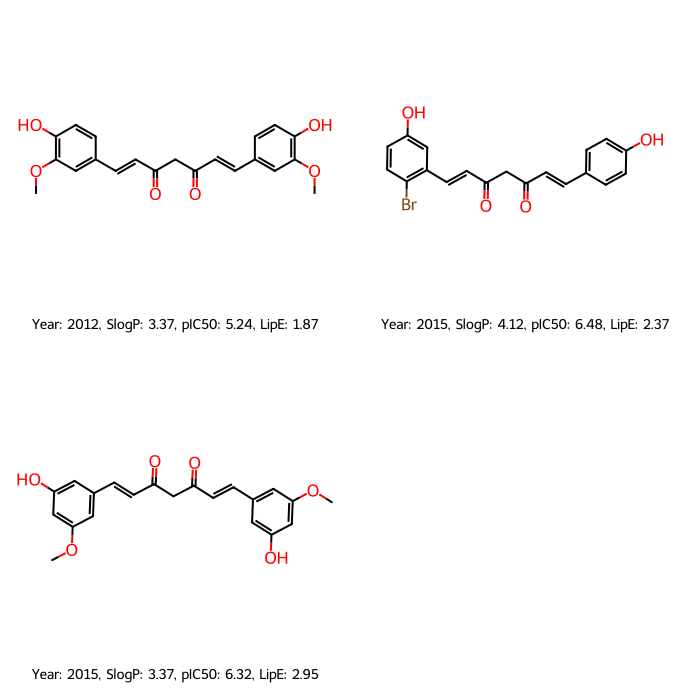

In [39]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw

database_potency["pIC50"] = 9 - np.log10(database_potency["Standard Value"])
database_potency["Document Year"] = pd.to_numeric(
    database_potency["Document Year"], errors="coerce"
)

top_6_smiles = scaffolds_counts.head(6)["Scaffold SMILES"].tolist()

ranking_elegido = 4
scaffold_smiles_elegido = top_6_smiles[ranking_elegido - 1]


df_scaffold_sel = database_potency[
    (database_potency["scaffolds_smiles"] == scaffold_smiles_elegido)
    & (database_potency["Document Year"].notna())
].copy()

df_scaffold_sel["Document Year"] = df_scaffold_sel["Document Year"].astype(int)

años_activos_scaffold = sorted(df_scaffold_sel["Document Year"].unique())


moleculas_a_dibujar = []
leyendas = []

columna_mol_smiles = "Smiles"
columna_slogp = "SlogP"
columna_ic50 = "pIC50"
columna_lipe = "LipE"

for año in años_activos_scaffold:
    df_año_especifico = df_scaffold_sel[df_scaffold_sel["Document Year"] == año]

    df_dos_compuestos = df_año_especifico.head(2)

    for idx, fila in df_dos_compuestos.iterrows():
        smiles = fila[columna_mol_smiles]
        slogp = fila[columna_slogp]
        ic50 = fila[columna_ic50]
        lipe = fila[columna_lipe]

        mol = Chem.MolFromSmiles(str(smiles))
        if mol is not None:
            moleculas_a_dibujar.append(mol)
            leyendas.append(
                f"Year: {año}, SlogP: {slogp:.2f}, pIC50: {ic50:.2f}, LipE: {lipe:.2f}"
            )


print(f"📊 Analizando Scaffold Ranking {ranking_elegido}")
print(
    f"-> Años detectados para este núcleo: {años_activos_scaffold} (Total: {len(años_activos_scaffold)} años)"
)
print(f"-> Cantidad total de estructuras en el grid: {len(moleculas_a_dibujar)}")

drawer_options = Draw.MolDrawOptions()
drawer_options.legendFontSize = 14
drawer_options.baseFontSize = 1.1
drawer_options.bondLineWidth = 2


top = Draw.MolsToGridImage(
    moleculas_a_dibujar,
    molsPerRow=2,
    subImgSize=(350, 350),
    legends=leyendas,
    drawOptions=drawer_options,
)

top